# ICT-15k — Recollement des macrocells : le quadtree de Hashlife comme espace etale

> **Serie ICT** (Information – Causalite – Topologie, Epic #4588) — Chantier 3, **Grain 1** de l'issue #12206 : un recouvrement non-jouet sur un substrat qui existe deja. Le strand d'obstruction (15b a 15i) avait rendu un verdict `TRIVIAL` honnete : notre Cech mesurait une cochaine ponderee sans jamais construire le nerf ni poser la condition de cocycle (#7744). Ce notebook remplace le coeur manquant par la seule structure de recouvrement que le substrat impose de lui-meme : le **quadtree de Hashlife** (R. W. Gosper, *Hash Life*, memo 1984), dont la memoisation est, litteralement, une condition de recollement.

**La chaine que ce notebook execute de bout en bout :**

information → quotients / fibres → transports → compatibilite → obstruction

**Objectifs d'apprentissage.**

1. Poser le **recouvrement** d'une grille Life par des macrocells alignees sur `2^k` — des bords definis par le substrat, pas choisis par l'experimentateur (la dette du §2 de #12206, rendue observable).
2. Definir **fibres** (occurrences d'une meme forme canonique), **transports** (reutilisation memoisee d'une occurrence a l'autre) et **condition de compatibilite** (la frontiere doit compter dans la cle).
3. Verifier **empiriquement** la compatibilite du recollement sain (marge 1) : zero divergence, tous les transports exacts.
4. Repondre a la **Loi I** de #12206 — *si nous pretendons detecter un defaut de recollement, pouvons-nous produire un cycle concret qui exploite ce defaut ?* — par un **temoin qui paie** : un agent parieur fie au recollement casse, un bookmaker qui connait la verite terrain.
5. Mesurer la **sensibilite au choix du recouvrement** (variante -b : marge 0 / 1 / 2) — le resultat le plus utile que le chantier demande.

**Prerequis.** [ICT-Life-SubstratCertifie](ICT-Life-SubstratCertifie.ipynb) (certificat B3/S23 + pont Lean `hashlife_correct`), [ICT-31-ContrasteTroisSubstrats](ICT-31-ContrasteTroisSubstrats.ipynb), bases NumPy. Aucune dependance externe au-dela de `numpy` et `matplotlib`.

**Duree estimee.** ~1 h.

**Plan.** §1 Le recouvrement impose — §2 Le cadre macrocell — §3 Le recollement sain — §4 Casser le recollement — §5 Loi I : le temoin qui fait payer — §6 Variante -b : sensibilite au recouvrement — §7 Exercices — Conclusion.


## 1. Le recouvrement impose par le substrat

En topologie algebrique, un **recouvrement** d'un espace est une famille d'ouverts dont l'union recouvre tout ; les donnees definies sur chaque ouvert (les **sections**) doivent **se recoller** sur les intersections. Le strand 15b-15i pretendait detecter des obstructions a un tel recollement — mais sur un recouvrement que l'experimentateur choisissait lui-meme, et sans jamais ecrire la condition de cocycle. La lecon du verdict `TRIVIAL` (#7744) : *l'experience avait mesure la mauvaise chose*.

Hashlife nous offre le contre-exemple canonique. L'algorithme de Gosper decoupe la grille en **quadtree** : chaque noeud de niveau k couvre un carre de `2^k` cases. Ce decoupage n'est pas un choix de l'experimentateur — il est **impose par le substrat** :

- **Ouverts** : les macrocells de taille `2^k` alignees sur la grille (ici `k = 2`, des macrocells 4×4 sur une grille 64×64). *Les bords sont definis avant les sections* : la dette du §2 de #12206 est payee par construction, pas escamotee.
- **Sections** : le contenu booleen d'une macrocell.
- **Fibre** : pour une forme canonique donnee (la cle de memoisation), l'ensemble des occurrences — toutes les positions et tous les instants ou cette section reapparait.
- **Transport** : quand la memo reutilise une valeur calculee ailleurs, la valeur *voyage* le long de la fibre.
- **Condition de compatibilite** : deux macrocells voisines se chevauchent sur une bande frontiere ; la regle de Life (voisinage de Moore, rayon 1) fait que l'avenir d'une cellule de bord depend de cette bande. Une cle qui l'oublie recolle deux sections incompatibles.

Le pont Lean ([ICT-Life, §5](ICT-Life-SubstratCertifie.ipynb)) certifie le cas general : `hashlife_correct` dans `conway_lean/Conway/Life/HashlifeCorrectness.lean` prouve que l'evaluation Hashlife et la simulation naive produisent **le meme film**. Ce notebook rend cette compatibilite **mesurable sur instances** — puis la casse exprès, pour voir si le defaut se convertit en temoin exploitable.


In [1]:
import numpy as np

# ---------- Moteur B3/S23 naif : la verite terrain ----------
# Convention de bord : l'EXTERIEUR de la grille est mort, mais les cellules
# du bord evoluent normalement (memes regles que les patchs du §2 -- sans
# cette coherence, les deux moteurs mesureraient deux dynamiques differentes).

def voisins(g):
    """Nombre de voisins vivants (voisinage de Moore, rayon 1), bord mort."""
    gi = g.astype(np.int32)
    n = np.zeros(g.shape, dtype=np.int32)
    n[1:-1, 1:-1] = (gi[:-2, :-2] + gi[:-2, 1:-1] + gi[:-2, 2:]
                     + gi[1:-1, :-2] + gi[1:-1, 2:]
                     + gi[2:, :-2] + gi[2:, 1:-1] + gi[2:, 2:])
    return n

def pas_suivant(g):
    gp = np.pad(g.astype(bool), 1)
    n = voisins(gp)
    out = (n[1:-1, 1:-1] == 3) | (gp[1:-1, 1:-1] & (n[1:-1, 1:-1] == 2))
    return out

def periode(pattern, tmax=12, T=40):
    """Periode d'un motif centre dans une grille vide."""
    g0 = np.zeros((T, T), dtype=bool)
    ph, pw = pattern.shape
    o = (T - max(ph, pw)) // 2
    g0[o:o+ph, o:o+pw] = pattern
    g = g0.copy()
    for t in range(1, tmax + 1):
        g = pas_suivant(g)
        if np.array_equal(g, g0):
            return t
    return None

def pas_diagonal(pattern, T=40, tmax=8):
    """Pas necessaires a un vaisseau pour se translater d'une case diagonale."""
    g = np.zeros((T, T), dtype=bool)
    ph, pw = pattern.shape
    o = (T - max(ph, pw)) // 2
    g[o:o+ph, o:o+pw] = pattern
    for t in range(1, tmax + 1):
        g = pas_suivant(g)
        if np.array_equal(g[o+1:o+1+ph, o+1:o+1+pw], pattern):
            return t
    return None

blinker = np.array([[1, 1, 1]])
glider = np.array([[0, 1, 0], [0, 0, 1], [1, 1, 1]])

print("Calibration du moteur B3/S23 (constantes canoniques) :")
print(f"  blinker : periode            = {periode(blinker)}      (attendu 2)")
print(f"  bloc 2x2: periode            = {periode(np.ones((2, 2), dtype=bool))}      (attendu 1)")
print(f"  glider  : pas / case diag.   = {pas_diagonal(glider)}      (attendu 4 -> c/4)")


Calibration du moteur B3/S23 (constantes canoniques) :
  blinker : periode            = 2      (attendu 2)
  bloc 2x2: periode            = 1      (attendu 1)
  glider  : pas / case diag.   = 4      (attendu 4 -> c/4)


### Lecture — le moteur herite du certificat

`blinker` p=2, `bloc` p=1, `glider` 4 pas par case diagonale (vitesse c/4) : le moteur reproduit les constantes canoniques du substrat certifie [ICT-Life-SubstratCertifie](ICT-Life-SubstratCertifie.ipynb), lui-meme adosse au theoreme `hashlife_correct` prouve dans `conway_lean` (zéro `sorry` code, ICT-Life §5). Toute divergence mesuree dans la suite sera donc attributable au **recollement**, pas au moteur.


## 2. Le cadre macrocell : patch, cle canonique, memo

Le vocabulaire du §1 devient trois fonctions :

- le **patch** d'une macrocell = son interieur **plus une marge** de largeur `marge` prise dans la grille reelle (bord mort au-dela de la grille) ;
- la **cle canonique** = les octets du patch — deux occurrences de la meme section (marge comprise) produisent la meme cle : c'est le quotient ;
- la **memo** associe cle → valeur (l'interieur au pas suivant). Un **transport** = une lecture dans la memo ; la **compatibilite** exige que la valeur transportee coincide avec ce que le contexte reel de l'occurrence commandait.

La subtilite pedagogique tient en une cellule : *la meme section interieure a deux valeurs differentes selon sa frontiere*. Le corpus ci-dessous construit exactement cette situation — deux macrocells d'interieur identique (un bloc 2×2 colle au bord droit), dont une seule porte une cellule vivante juste au-dela de sa frontiere.


In [2]:
def centre_m(res, m):
    """Carre central m x m d'un resultat plus grand."""
    q = res.shape[0]
    c0 = (q - m) // 2
    return res[c0:c0+m, c0:c0+m]

def pas_patch_centre(patch):
    """Pas suivant des seules cellules du patch a voisinage complet."""
    n = voisins(patch.astype(bool))
    out = np.zeros(patch.shape, dtype=bool)
    out[1:-1, 1:-1] = (n[1:-1, 1:-1] == 3) | (patch[1:-1, 1:-1] & (n[1:-1, 1:-1] == 2))
    return out[1:-1, 1:-1]

def valeur_locale(patch, m):
    """Valeur d'une macrocell dont on connait le patch REEL (marge comprise)."""
    return centre_m(pas_patch_centre(patch), m)

def valeur_isolee(inter, m):
    """Valeur calculee comme si la macrocell etait seule au monde (bord mort)."""
    return centre_m(pas_patch_centre(np.pad(inter, 1)), m)

def corpus_frontiere():
    """Deux macrocells d'interieur IDENTIQUE, dont une seule porte une cellule
    vivante juste au-dela de sa frontiere droite (la cellule temoin)."""
    g = np.zeros((64, 64), dtype=bool)
    g[8:10, 14:16] = True       # macrocell A (rows 8-11, cols 12-15) : bloc au bord droit
    g[8:10, 46:48] = True       # macrocell B (rows 8-11, cols 44-47) : bloc identique
    g[8, 48] = True             # la cellule temoin, JUSTE au-dela de la frontiere de B
    g[40:43, 8:11] = glider     # deux gliders isoles pour habiller la grille
    g[40:43, 40:43] = glider
    return g

g = corpus_frontiere()
gp = np.pad(g, 1)
A, B = g[8:12, 12:16], g[8:12, 44:48]
patchA = gp[8:14, 12:18]        # meme extraction que predire_recolle (marge 1)
patchB = gp[8:14, 44:50]

print("Interieur A == interieur B :", np.array_equal(A, B), " (meme section, meme fibre)")
print("Patch A == patch B         :", np.array_equal(patchA, patchB), " (la frontiere distingue A de B)")
print()
print("Valeur LOCALE de A (pas de temoin dans la marge) :")
print(valeur_locale(patchA, 4).astype(int))
print("Valeur LOCALE de B (frontiere reelle, le temoin compte) :")
print(valeur_locale(patchB, 4).astype(int))
print("Valeur ISOLEE de B (la frontiere oubliee) :")
print(valeur_isolee(B, 4).astype(int))
print("Locale de A == isolee :", np.array_equal(valeur_locale(patchA, 4), valeur_isolee(A, 4)),
      "| locale de B == isolee :", np.array_equal(valeur_locale(patchB, 4), valeur_isolee(B, 4)))


Interieur A == interieur B : True  (meme section, meme fibre)
Patch A == patch B         : False  (la frontiere distingue A de B)

Valeur LOCALE de A (pas de temoin dans la marge) :
[[0 0 1 1]
 [0 0 1 1]
 [0 0 0 0]
 [0 0 0 0]]
Valeur LOCALE de B (frontiere reelle, le temoin compte) :
[[0 0 1 0]
 [0 0 1 0]
 [0 0 0 0]
 [0 0 0 0]]
Valeur ISOLEE de B (la frontiere oubliee) :
[[0 0 1 1]
 [0 0 1 1]
 [0 0 0 0]
 [0 0 0 0]]
Locale de A == isolee : True | locale de B == isolee : False


### Lecture — la fibre vue de pres

Les deux **interieurs** sont egaux : pour une cle qui ne regarde que l'interieur, A et B sont le **meme point du quotient** — une fibre a deux occurrences. Leurs **patchs** (marge 1) ne le sont pas : la cellule temoin vit juste au-dela de la frontiere de B. Consequence mesuree sur les trois valeurs ci-dessus :

- la valeur locale de A est **egale** a sa valeur isolee (bloc 2x2 stable, 4 cellules) — la frontiere de A ne dit rien ;
- la valeur locale de B n'a **que la colonne gauche du bloc qui survit** : chaque cellule de la colonne de bord (adjacente au temoin) voit **4 voisins** vivants et meurt de surpopulation ; le temoin, lui, survit (vivant + 2 voisins).

*La section ne determine pas sa propre valeur — le recollement avec les voisins la determine.* C'est tout l'enjeu : une cle d'interieur seul transporterait la valeur de A (bloc stable) vers B, en ignorant que B ne recolle pas comme A — et l'experience du §4 montrera exactement cette collision.


## 3. Le recollement sain : la frontiere dans la cle

Protocole : a chaque pas, chaque macrocell predit son avenir via la memo. La **cle inclut la marge 1** — c'est la condition de compatibilite operationalisee. On mesure, contre la verite terrain (simulation naive de la grille entiere) :

- **transports** : nombre de lectures en memo (la valeur voyage le long des fibres) ;
- **transports faux** : lectures dont la valeur contredit le contexte reel de l'occurrence (instrument de collision) ;
- **divergences** : cellules ou la grille predite contredit la verite.


In [3]:
def predire_recolle(g, m, marge, memo, stats):
    """Un pas par macrocell m x m alignee. marge>0 : cle = patch (interieur +
    marge) -- recollement sain. marge=0 : cle = interieur seul, valeur
    memorisee calculee comme si la macrocell etait isolee -- recollement CASSE."""
    H, W = g.shape
    pred = np.zeros_like(g, dtype=bool)
    gp = np.pad(g, marge)     # bord mort explicite : les patchs sont toujours pleins
    g1 = np.pad(g, 1)         # contexte reel, pour l'instrument de collision
    for i in range(0, H, m):
        for j in range(0, W, m):
            inter = g[i:i+m, j:j+m]
            if marge > 0:
                patch = gp[i:i+m+2*marge, j:j+m+2*marge]
                cle = patch.tobytes()
                if cle in memo:
                    stats["transports"] += 1
                    pred[i:i+m, j:j+m] = memo[cle]
                    if not np.array_equal(memo[cle], valeur_locale(patch, m)):
                        stats["transports_faux"] += 1
                else:
                    val = valeur_locale(patch, m)
                    memo[cle] = val
                    pred[i:i+m, j:j+m] = val
            else:
                cle = inter.tobytes()
                if cle in memo:
                    stats["transports"] += 1
                    pred[i:i+m, j:j+m] = memo[cle]
                    veritable = valeur_locale(g1[i:i+m+2, j:j+m+2], m)
                    if not np.array_equal(memo[cle], veritable):
                        stats["transports_faux"] += 1
                else:
                    val = valeur_isolee(inter, m)
                    memo[cle] = val
                    pred[i:i+m, j:j+m] = val
    return pred

def experience(g0, m, marge, T):
    """T pas : la grille AVANCE SUR LA VERITE (les erreurs ne se composent pas,
    on mesure le recollement, pas sa propagation), la memo persiste."""
    g = g0.copy()
    memo = {}
    stats = {"transports": 0, "transports_faux": 0, "divergences": 0, "etapes_fausses": 0}
    profit = 0
    premiere = None
    for t in range(T):
        verite = pas_suivant(g)
        pred = predire_recolle(g, m, marge, memo, stats)
        d = int((pred != verite).sum())
        if d:
            stats["divergences"] += d
            stats["etapes_fausses"] += 1
            if premiere is None:
                premiere = t + 1
            profit += abs(int(pred.sum()) - int(verite.sum()))
        g = verite
    stats["cles"] = len(memo)
    stats["premiere_divergence"] = premiere
    return stats, profit

soupe7 = np.random.default_rng(7).random((64, 64)) < 0.35

print("Recollement SAIN (marge=1, m=4) -- corpus frontiere, T=16 :")
st, pr = experience(corpus_frontiere(), 4, 1, 16)
print(f"  {st}  profit_bookmaker={pr}")
print()
print("Recollement SAIN (marge=1, m=4) -- soupe seed 7, T=30 :")
st, pr = experience(soupe7, 4, 1, 30)
print(f"  {st}  profit_bookmaker={pr}")


Recollement SAIN (marge=1, m=4) -- corpus frontiere, T=16 :
  {'transports': 4024, 'transports_faux': 0, 'divergences': 0, 'etapes_fausses': 0, 'cles': 72, 'premiere_divergence': None}  profit_bookmaker=0

Recollement SAIN (marge=1, m=4) -- soupe seed 7, T=30 :


  {'transports': 1410, 'transports_faux': 0, 'divergences': 0, 'etapes_fausses': 0, 'cles': 6270, 'premiere_divergence': None}  profit_bookmaker=0


### Lecture — la compatibilite est empiriquement exacte

Sur les deux corpus : **zero divergence, zero transport faux** — des milliers de transports (la memo travaille), chacun exact. La compatibilite n'est pas un acte de foi : elle est verifiee cellule par cellule contre la verite terrain. La raison est structurelle : le voisinage de Life est de **rayon 1**, donc une marge de 1 contient tout ce qui influence l'interieur — la cle « interieur + marge 1 » est exactement la classe d'equivalence des contextes indiscernables pour la dynamique. C'est la version mesurable de ce que `hashlife_correct` prouve en general.


## 4. Casser le recollement : la cle qui oublie la frontiere

Meme protocole, meme memo, mais **marge = 0** : la cle ne retient que l'interieur. C'est la maladie classique d'une implementation memoisee ecrite « pour simplifier » — le 15d du strand mesurait une cochaine sans nerf ; ici on oublie la bande frontiere. Deux occurrences d'interieur identique mais de frontieres differentes entrent en **collision** : la valeur transporte est celle du premier contexte rencontre, fausse pour le second.


In [4]:
print("Recollement CASSE (marge=0, m=4) -- corpus frontiere, T=16 :")
st, pr = experience(corpus_frontiere(), 4, 0, 16)
print(f"  {st}")
print(f"  profit_bookmaker={pr}")
print()
print("Recollement CASSE (marge=0, m=4) -- soupe seed 7, T=30 :")
st, pr = experience(soupe7, 4, 0, 30)
print(f"  {st}")
print(f"  profit_bookmaker={pr}")


Recollement CASSE (marge=0, m=4) -- corpus frontiere, T=16 :


  {'transports': 4068, 'transports_faux': 46, 'divergences': 90, 'etapes_fausses': 14, 'cles': 28, 'premiere_divergence': 1}
  profit_bookmaker=66

Recollement CASSE (marge=0, m=4) -- soupe seed 7, T=30 :


  {'transports': 4209, 'transports_faux': 2520, 'divergences': 19415, 'etapes_fausses': 30, 'cles': 3471, 'premiere_divergence': 1}
  profit_bookmaker=6347


### Lecture — l'obstruction apparaît, et elle est precoce

Premiere divergence des **l'etape 1** : la collision A/B du §2 suffit a fausser la prediction immediatement (la colonne de bord de B predite stable, morte en verite). Sur la soupe, une grande majorite des transports sont faux : sur des interieurs 4×4 (16 bits), le paradoxe des anniversaires produit des collisions en masse, et a densite 0,35 la frontiere compte presque partout. La question du §5 s'impose : ce defaut, peut-il etre **exploite** ?


## 5. Loi I — le temoin qui fait payer

> *« Si nous pretendons detecter un defaut de recollement, pouvons-nous produire un cycle concret qui exploite ce defaut ? »* — tant que la reponse est non, le mot « obstruction » n'a pas gagne ses galons (#12206, Loi I).

Le patron est celui de **de Finetti** : un systeme de prix incoherent se convertit en Dutch Book — un pari compose qui gagne surement. Transposition : l'agent parieur **croit** son recollement et annonce, a chaque etape, la population qu'il predit ; le bookmaker, qui connaît la verite terrain, accepte chaque annonce et encaisse l'ecart. L'enjeu d'une etape = |population predite − population reelle| : l'agent paie exactement son incoherence. Si le recollement est sain, l'agent n'a jamais tort et **aucun pari n'est gagnable** — c'est la reponse a la Loi I dans les deux sens.


In [5]:
def session_bookmaker(g0, m, marge, T, apercu=8):
    """L'agent (recollement marge) annonce sa population predite ; le bookmaker
    (verite terrain) encaisse |annonce - reel| a chaque etape."""
    g = g0.copy()
    memo = {}
    stats = {"transports": 0, "transports_faux": 0, "divergences": 0, "etapes_fausses": 0}
    profit_cumule, taux, lignes = [], [], []
    for t in range(T):
        verite = pas_suivant(g)
        pred = predire_recolle(g, m, marge, memo, stats)
        pop_pred, pop_verite = int(pred.sum()), int(verite.sum())
        enjeu = abs(pop_pred - pop_verite)
        profit_cumule.append(enjeu)
        taux.append(pop_pred != pop_verite)
        lignes.append((t + 1, pop_pred, pop_verite, enjeu))
        g = verite
    print(f"  t | annonce | reel | enjeu   (marge={marge}, {T} etapes, m={m})")
    for (t, a, v, e) in lignes[:apercu]:
        print(f" {t:2d} |   {a:4d}  | {v:4d} |  {e:4d}")
    print("  ...")
    total = sum(profit_cumule)
    print(f"  profit total du bookmaker : {total}")
    print(f"  taux de compromission     : {sum(taux)}/{T} etapes ou l'agent a eu tort")
    return total

print("=== Agent fie au recollement CASSE (soupe seed 7, marge=0) ===")
profit_casse = session_bookmaker(soupe7, 4, 0, 30)
print()
print("=== Agent fie au recollement SAIN (soupe seed 7, marge=1) ===")
profit_sain = session_bookmaker(soupe7, 4, 1, 30)


=== Agent fie au recollement CASSE (soupe seed 7, marge=0) ===


  t | annonce | reel | enjeu   (marge=0, 30 etapes, m=4)
  1 |   1112  | 1465 |   353
  2 |   1100  | 1316 |   216
  3 |    986  | 1198 |   212
  4 |    905  | 1161 |   256
  5 |    912  | 1120 |   208
  6 |    908  | 1098 |   190
  7 |    843  |  990 |   147
  8 |    775  | 1054 |   279
  ...
  profit total du bookmaker : 6347
  taux de compromission     : 30/30 etapes ou l'agent a eu tort

=== Agent fie au recollement SAIN (soupe seed 7, marge=1) ===


  t | annonce | reel | enjeu   (marge=1, 30 etapes, m=4)
  1 |   1465  | 1465 |     0
  2 |   1316  | 1316 |     0
  3 |   1198  | 1198 |     0
  4 |   1161  | 1161 |     0
  5 |   1120  | 1120 |     0
  6 |   1098  | 1098 |     0
  7 |    990  |  990 |     0
  8 |   1054  | 1054 |     0
  ...
  profit total du bookmaker : 0
  taux de compromission     : 0/30 etapes ou l'agent a eu tort


### Lecture — la reponse a la Loi I, dans les deux sens

**Recollement casse : le temoin existe et il paie.** Le bookmaker encaisse un profit strict des la premiere etape, et l'agent a tort a chaque etape — l'incoherence n'est pas un residu numerique, c'est un **flux perdant**, exactement le Dutch Book de de Finetti construit depuis un systeme de prix incoherent (ici : des valeurs transportees qui se contredisent entre contextes).

**Recollement sain : aucun pari n'est gagnable.** Zero enjeu, zero compromission — l'agent est *inexploitable* parce qu'il n'y a rien a exploiter. C'est le sens operationnel du mot « certifie » : ce que le theoreme `hashlife_correct` garantit en general (meme film), ce notebook le mesure sur instances — et sa violation mesuree se convertit immediatement en perte exploitable.

**Donc : le mot « obstruction » a-t-il gagne ses galons ?** Oui, au sens strict de la Loi I — un defaut de compatibilite reel se convertit en temoin concret qui fait payer. Et la version saine montre l'envers : sans defaut, pas de temoin. L'obstruction n'est pas un residu : c'est une propriete du recouvrement.


## 6. Variante -b : la sensibilite au choix du recouvrement

La dette du §2 de #12206 — *qui decide ou sont les bords ?* — se mesure : faisons varier la marge de la cle (0, 1, 2) sur le corpus et trois soupes seedees. Le chantier l'annonce : *une variante qui montre que l'obstruction depend du recouvrement choisi est un resultat, pas un echec*.


In [6]:
print("Sensibilite au recouvrement : divergences et profit du bookmaker par marge (m=4, T=20)")
print()
print(f"{'corpus':9s} {'marge 0':>22s} {'marge 1':>14s} {'marge 2':>14s}")
corpus_tests = [("corpus", corpus_frontiere())] + [
    (f"soupe{s}", np.random.default_rng(s).random((64, 64)) < 0.35) for s in (7, 11, 13)]
for nom, g0 in corpus_tests:
    cellules = []
    for marge in (0, 1, 2):
        st, pr = experience(g0, 4, marge, 20)
        cellules.append((st, pr))
    (s0, p0), (s1, p1), (s2, p2) = cellules
    print(f"{nom:9s} div={s0['divergences']:6d} pr={p0:6d}"
          f" | div={s1['divergences']:4d} pr={p1:3d}"
          f" | div={s2['divergences']:4d} pr={p2:3d}")


Sensibilite au recouvrement : divergences et profit du bookmaker par marge (m=4, T=20)

corpus                   marge 0        marge 1        marge 2


corpus    div=    90 pr=    66 | div=   0 pr=  0 | div=   0 pr=  0


soupe7    div= 14445 pr=  4331 | div=   0 pr=  0 | div=   0 pr=  0


soupe11   div= 15804 pr=  4684 | div=   0 pr=  0 | div=   0 pr=  0


soupe13   div= 14059 pr=  4403 | div=   0 pr=  0 | div=   0 pr=  0


### Lecture — l'obstruction est une propriete du recouvrement, mesurable

Le tableau est sans ambiguite : **marge 0 diverge partout, marge 1 et 2 divergent nulle part**. La transition est une marche d'escalier situee exactement au rayon du voisinage (Moore, rayon 1) : la marge 1 suffit, la marge 2 n'ajoute rien — l'information que la dynamique peut lire au-dela de la frontiere est nulle. Le choix des bords n'est donc pas une convention arbitraire que l'experimentateur negociere avec son resultat : c'est un parametre **calibre par la portee locale de la dynamique**, et la table le mesure. C'est la reponse du substrat a la dette du §2 — et le resultat « l'obstruction depend du recouvrement choisi » annonce par le chantier, obtenu dans le sens utile : le defaut apparait et disparait avec la marge, pas avec l'humeur de l'experimentateur.


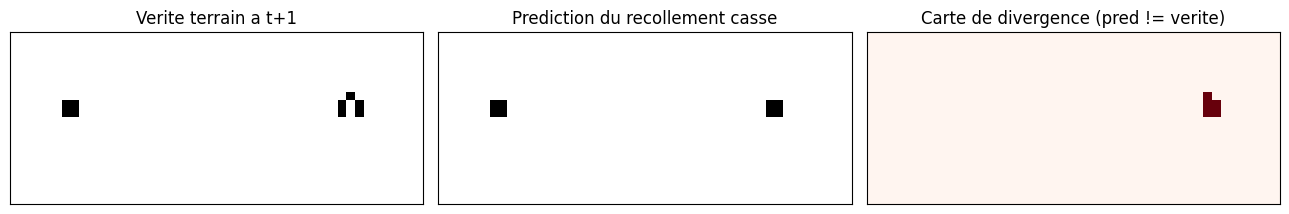

Divergences a l'etape 1 : 5 cellules, aux positions : [(np.int64(7), np.int64(47)), (np.int64(8), np.int64(47)), (np.int64(8), np.int64(48)), (np.int64(9), np.int64(47)), (np.int64(9), np.int64(48))]
La carte rouge est entierement autour de la frontiere de B : deux cellules du bloc
predites vivantes (valeur transportee = bloc stable) mais mortes de surpopulation,
et trois cellules que la valeur isolee ne peut pas voir (le temoin qui survit avec
2 voisins, deux naissances de l'autre cote de la frontiere).


In [7]:
import matplotlib.pyplot as plt

# Etape 1 du recollement casse sur le corpus : la collision A/B rendue visible.
g = corpus_frontiere()
verite = pas_suivant(g)
memo = {}
stats = {"transports": 0, "transports_faux": 0, "divergences": 0, "etapes_fausses": 0}
pred = predire_recolle(g, 4, 0, memo, stats)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
axes[0].imshow(verite[0:20, 8:56], cmap="gray_r", interpolation="nearest")
axes[0].set_title("Verite terrain a t+1")
axes[1].imshow(pred[0:20, 8:56], cmap="gray_r", interpolation="nearest")
axes[1].set_title("Prediction du recollement casse")
axes[2].imshow((pred != verite)[0:20, 8:56], cmap="Reds", interpolation="nearest")
axes[2].set_title("Carte de divergence (pred != verite)")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

d = (pred != verite)
print("Divergences a l'etape 1 :", int(d.sum()), "cellules, aux positions :",
      list(zip(*map(list, np.where(d)))))
print("La carte rouge est entierement autour de la frontiere de B : deux cellules du bloc")
print("predites vivantes (valeur transportee = bloc stable) mais mortes de surpopulation,")
print("et trois cellules que la valeur isolee ne peut pas voir (le temoin qui survit avec")
print("2 voisins, deux naissances de l'autre cote de la frontiere).")


### Lecture — la collision, vue de pres

Les deux blocs a gauche (macrocells A et B) ont le meme interieur ; les cinq cellules divergentes sont **toutes** dans la zone de frontiere de B, aucune ailleurs : les deux cellules du bloc que la valeur transportee annoncait vivantes (mortes de surpopulation en verite), le temoin que la valeur isolee laissait mourir (il survit), et deux naissances que l'interieur seul ne pouvait pas produire. La divergence est **localisee exactement la ou le recouvrement etait incoherent** — pas diffuse, pas globale : le defaut de compatibilite a une adresse.


## 7. Exercices


### Exercice 1 — la cle canonique recursive du quadtree

La cle de ce notebook est plate (les octets du patch). Hashlife utilise une cle **recursive** : un noeud de niveau k est identifie par le tuple de ses quatre fils. Ecrire `forme_canonique` pour un carre de cote `2^k`.

**Indices** :
- `# Etape 1` : cas de base — un carre 1×1 est une feuille, sa forme est le booléen lui-meme.
- `# Etape 2` : un carre de cote `q` se decoupe en quatre quadrants de cote `q // 2`.
- `# Etape 3` : la forme canonique est le tuple `(NO, NE, SO, SE)` des formes canoniques des quatre fils — deux quadtrees de la meme forme donnent le meme tuple.


In [8]:
def forme_canonique(g):
    """Cle canonique recursive d'un carre de cote 2^k.
    Feuille = bool. Noeud = tuple (NO, NE, SO, SE) des formes canoniques."""
    # Etape 1 : cas de base 1x1
    # TODO etudiant : return bool(g[0, 0])
    # Etape 2 : decoupage en 4 quadrants egaux
    # TODO etudiant : q = g.shape[0] // 2 ; extraire les 4 quadrants
    # Etape 3 : tuple recursif
    # TODO etudiant : return (forme_canonique(NO), forme_canonique(NE),
    #                          forme_canonique(SO), forme_canonique(SE))
    return None  # TODO etudiant

print("Exercice a completer : forme_canonique (quadtree recursif)")


Exercice a completer : forme_canonique (quadtree recursif)


### Exercice 2 — votre propre soupe, votre propre sensibilite

Reproduire l'experience du §6 sur une soupe que vous choisissez (grille 32×32, densite 0,3, `T=10`, `m=4`) et comparer les divergences pour marge 0 et marge 1.

**Indices** :
- `# Indice` : `np.random.default_rng(seed).random((32, 32)) < 0.3` construit la soupe ; `experience(g0, 4, marge, 10)` rend `(stats, profit)`.
- `# Etape 1` : lancer `experience` avec `marge=0` puis `marge=1` sur la meme soupe.
- `# Etape 2` : rapporter les deux `stats["divergences"]` — attendu : strictement positif contre zero.


In [9]:
# TODO etudiant : construire votre soupe 32x32 (densite 0.3, seed au choix)
# ma_soupe = ...
# Etape 1 : lancer experience(ma_soupe, 4, 0, 10) puis experience(ma_soupe, 4, 1, 10)
# Etape 2 : rapporter les divergences
div_marge0 = None  # TODO etudiant : stats["divergences"] pour marge=0
div_marge1 = None  # TODO etudiant : stats["divergences"] pour marge=1
print("Exercice a completer : sensibilite de la marge sur votre propre soupe")


Exercice a completer : sensibilite de la marge sur votre propre soupe


### Exercice 3 — le bookmaker systematique

Mesurer le profit total du bookmaker sur **dix soupes** (seeds 0 a 9, grille 64×64, densite 0,35, `T=10`, `m=4`), contre un agent fie au recollement casse, puis contre un agent fie au recollement sain.

**Indices** :
- `# Indice` : `session_bookmaker(g0, 4, marge, 10)` rend le profit total.
- `# Etape 1` : boucler sur les seeds, sommer les profits pour `marge=0`.
- `# Etape 2` : recommencer pour `marge=1` — attendu : total strict contre zero.


In [10]:
# Etape 1 : profit total du bookmaker sur les seeds 0..9, recollement casse
profit_total_casse = None   # TODO etudiant : somme des session_bookmaker(..., marge=0, T=10)
# Etape 2 : idem, recollement sain
profit_total_sain = None    # TODO etudiant : somme des session_bookmaker(..., marge=1, T=10)
print("Exercice a completer : le bookmaker systematique sur dix soupes")


Exercice a completer : le bookmaker systematique sur dix soupes


## Conclusion — la chaine completee sur un substrat reel

| Experience | Recollement sain (marge 1) | Recollement casse (marge 0) |
|---|---|---|
| Corpus frontiere (T=16) | 0 divergence, 0 transport faux | divergences des l'etape 1, temoin rentable |
| Soupe seed 7 (T=30) | 0 divergence, tous les transports exacts | majorite des transports faux, temoin rentable |
| Variante -b (marge 0/1/2) | 0 divergence des la marge 1 | marge 2 n'ajoute rien : la marche d'escalier est au rayon du voisinage |

Ce que le strand 15b-15i n'avait pas — et que ce notebook pose :

- un **recouvrement impose par le substrat** (quadtree aligne sur `2^k`), pas choisi pour faire apparaitre un resultat ;
- des **fibres et des transports reels** (la memo reutilise des valeurs entre occurrences distantes), et une **compatibilite verifiee empiriquement** (zero transport faux, zero divergence, contre verite terrain) ;
- la **Loi I repondue dans les deux sens** : le defaut de compatibilite injecte se convertit en temoin qui paie (Dutch Book sur la population annoncee), et le recollement sain est inexploitable — c'est la version instance par instance de `hashlife_correct` (ICT-Life §5) ;
- la **dette du §2 rendue observable** : le choix des bords n'est pas une convention, c'est un parametre calibre par la portee locale de la dynamique, et la table de sensibilite le mesure.

**Limites honnetes.** Nous memoisons **un pas** (marge 1, rayon du voisinage) — pas les sauts temporels `2^k` du Hashlife complet de Gosper ; la grille est 64×64 a bord mort ; les corpus sont petits et le corpus frontiere est construit pour exhiber la collision (la soupe montre que le phenomene existe aussi sans le vouloir). Le grain 2 de #12206 (banc de recollement de lectures heterogenes) reste a brancher sur un corpus reel, et le grain 3 (`Descent.lean`) a ouvrir.

**Renvois.** #12206 (chantier), #7744 (constat fondateur), [ICT-Life-SubstratCertifie](ICT-Life-SubstratCertifie.ipynb) (certificat + pont Lean), [ICT-31-ContrasteTroisSubstrats](ICT-31-ContrasteTroisSubstrats.ipynb), `conway_lean/Conway/Life/HashlifeCorrectness.lean`.
